# The StockKeep Class — End-to-End Inventory Planning

`StockKeep` is the top-level orchestrator in OptiStock. It chains four stages into a single call:

> **Fit forecaster → Forecast demand → Optimise allocation → Evaluate**

It supports two modes:

| Mode | Method | Purpose |
|---|---|---|
| **Holdout validation** | `run_holdout(holdout_days)` | Withhold recent history, forecast it, then compare the optimised allocation against what actually happened — use this to verify the methodology before going live |
| **Production** | `run(forecast_days)` | Fit on all available data and produce an allocation for the next *n* days |

Both modes accept the same solver and objective parameters (`objective`, `limits`, `cvar_alpha`, …), so you can test a risk-averse strategy in holdout mode before committing to it in production.

History: 1,460 rows | 2 items | 2022-01-01 → 2023-12-31


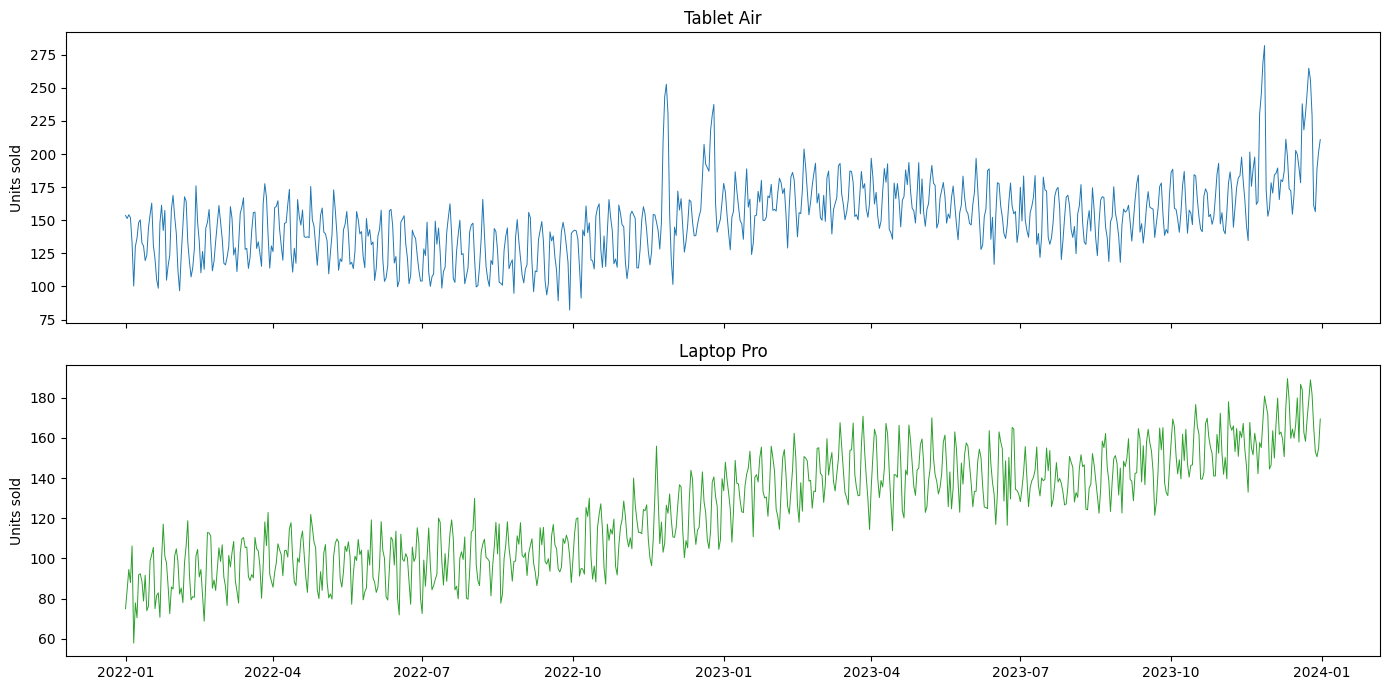

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

# ── Synthetic histories ────────────────────────────────────────────────────
# Two years of daily sales for two products.
#
# Tablet Air — consumer electronics:
#   · Moderate upward trend
#   · Strong weekend spike (people buy on Saturdays)
#   · Annual wave (Q4 gifting season peak)
#   · Black Friday and Christmas event spikes
#   · BetaYield(8, 2): ~80% of ordered units pass quality control
#
# Laptop Pro — business laptop:
#   · Steeper trend (enterprise demand growing)
#   · Mild weekly pattern (purchases cluster Mon–Wed)
#   · Softer seasonal curve
#   · Perfect yield (all ordered units arrive)

N = 730
dates = pd.date_range("2022-01-01", periods=N, freq="D")
t = np.arange(N)

# ── Tablet Air ─────────────────────────────────────────────────────────────
trend_ta      = 120 + 0.08 * t
weekly_ta     = 18 * np.sin(2 * np.pi * t / 7) + 8 * np.cos(2 * np.pi * t / 7)
yearly_ta     = (12 * np.sin(2 * np.pi * t / 365.25)
               +  8 * np.cos(2 * np.pi * t / 365.25))

event_ta = np.zeros(N)
for i, d in enumerate(dates):
    if d.month == 11 and d.weekday() == 4 and 22 <= d.day <= 28:   # Black Friday
        event_ta[i : min(i + 4, N)] += 80
    if d.month == 12 and 20 <= d.day <= 26:                         # Christmas week
        event_ta[i] += 60

sales_ta = trend_ta + weekly_ta + yearly_ta + event_ta + np.random.normal(0, 10, N)

# ── Laptop Pro ─────────────────────────────────────────────────────────────
trend_lp   = 80 + 0.12 * t
weekly_lp  = 12 * np.sin(2 * np.pi * t / 7) - 6 * np.cos(2 * np.pi * t / 7)
yearly_lp  = (8 * np.sin(2 * np.pi * t / 365.25)
            + 5 * np.cos(2 * np.pi * t / 365.25))

sales_lp = trend_lp + weekly_lp + yearly_lp + np.random.normal(0, 8, N)

# ── Combine into long-format DataFrame ─────────────────────────────────────
df_ta = pd.DataFrame({
    "item":  "Tablet Air",
    "date":  dates.astype(str),
    "sales": np.maximum(sales_ta, 5).round(1),
})
df_lp = pd.DataFrame({
    "item":  "Laptop Pro",
    "date":  dates.astype(str),
    "sales": np.maximum(sales_lp, 5).round(1),
})
df_history = pd.concat([df_ta, df_lp], ignore_index=True)

print(f"History: {df_history.shape[0]:,} rows | {df_history['item'].nunique()} items | "
      f"{df_history['date'].min()} → {df_history['date'].max()}")

# ── Quick overview ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, item, color in zip(axes, ["Tablet Air", "Laptop Pro"], ["tab:blue", "tab:green"]):
    sub = df_history[df_history["item"] == item]
    ax.plot(pd.to_datetime(sub["date"]), sub["sales"], lw=0.7, color=color)
    ax.set_title(item)
    ax.set_ylabel("Units sold")
plt.tight_layout()

In [18]:
from optistock.stockkeep import StockKeep
from optistock.forecasting.linear_regressors import BayesTimeSeries
from optistock.distributions.yield_distributions import BetaYield

# ── Item configuration ──────────────────────────────────────────────────────
# Required columns:   name, cost_price, selling_price
# Optional columns:   salvage_value (defaults to 0), plus any resource columns
#                     (extra columns become constraint coefficients on the solver)
item_configs = pd.DataFrame([
    {
        "name":          "Tablet Air",
        "cost_price":    120,
        "selling_price": 250,
        "salvage_value":  40,
        "storage_m3":    0.8,   # cubic metres of warehouse space per unit
    },
    {
        "name":          "Laptop Pro",
        "cost_price":    400,
        "selling_price": 750,
        "salvage_value": 100,
        "storage_m3":    2.0,
    },
])

# ── Forecaster configuration ────────────────────────────────────────────────
# We use BayesTimeSeries for both items.  The seasonal_config is passed via
# forecaster_kwargs and applied at construction time for every item.
seasonal_config = {
    "weekly": (7, 3),          # 7-day period, 3 sin/cos pairs
    "yearly": (365.25, 4),     # yearly cycle, 4 harmonics
}

# ── Yield distributions ─────────────────────────────────────────────────────
# Tablet Air has imperfect yield: on average 80% of ordered units pass QC.
# Laptop Pro is assumed to have perfect yield (all units arrive as ordered).
yield_profiles = {
    "Laptop Pro": BetaYield(8, 2),    # mean = 8/(8+2) = 80%
}

# ── Instantiate StockKeep ───────────────────────────────────────────────────
sk = StockKeep(
    histories=df_history,
    item_configs=item_configs,
    forecaster_class=BayesTimeSeries,
    forecaster_kwargs={"seasonal_config": seasonal_config},
    yield_profiles=yield_profiles,
    target="sales",
    date_col="date",
    item_col="item",
)

print("Items registered:")
for item in sk.items:
    cf = item.critical_fractile
    print(f"  {item.name:12s}  cost={item.cost_price:>4}  sell={item.selling_price:>4}  "
          f"salvage={item.salvage_value:>4}  critical_fractile={cf:.3f}")

Items registered:
  Tablet Air    cost=120.0  sell=250.0  salvage=40.0  critical_fractile=0.619
  Laptop Pro    cost=400.0  sell=750.0  salvage=100.0  critical_fractile=0.538


---
## Holdout Validation

Before committing to a strategy in production, use `run_holdout` to back-test it against real history.

`StockKeep` withholds the last `holdout_days` calendar days from each item's history, fits the forecaster on everything before that window, and then:
1. Generates a forecast over the withheld window.
2. Passes `(Item, fitted_forecaster)` pairs to `ForecastSolver` to find the optimal order quantities.
3. Simulates what would have happened if those quantities had been ordered — using the *actual* holdout sales as ground truth.

The returned `metrics` dict reports per-item profit, service level, stockout flag, leftover units, and **SMAPE** (forecast accuracy).

### Objective: CVaR
We use the CVaR objective here to protect against the worst 10% of demand scenarios.  This is appropriate for the Tablet Air whose yield adds extra uncertainty on top of forecast uncertainty.

In [19]:
# ── Known promotional events for Tablet Air ────────────────────────────────
all_dates = pd.to_datetime(df_history["date"].unique())
bf_dates   = [d for d in all_dates if d.month == 11 and d.weekday() == 4 and 22 <= d.day <= 28]
xmas_dates = [d for d in all_dates if d.month == 12 and 20 <= d.day <= 26]

events = {
    "Tablet Air": {
        "black_friday": [str(d.date()) for d in bf_dates],
        "christmas":    [str(d.date()) for d in xmas_dates],
    }
    # No events registered for Laptop Pro (business demand, no major promo spikes)
}

# ── Run holdout validation ─────────────────────────────────────────────────
# Withhold the last 30 days.
# Solver: CVaR (alpha=0.10 → protect the worst 10% of scenarios, lambda=0.60).
# Constraint: combined warehouse space ≤ 7,000 m³.
holdout_results = sk.run_holdout(
    holdout_days=14,
    events=events,
    objective="CVaR",
    limits={"storage_m3": 7_000},
    cvar_alpha=0.10,
    cvar_lambda=0.4,
    fit_kwargs={"chain": 2, "samples": 500},
)

print("Planning period:", holdout_results["period"])
print("Mode           :", holdout_results["mode"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 21 seconds.
Sampling: [y]


Output()

Sampling: [y]


...

Output()

Sampling: [y]


Output()

Planning period: ('2023-12-18', '2023-12-31')
Mode           : holdout


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:237: RuntimeWarning: divide by zero encountered in divide
  eu = float(np.mean(np.exp(-profits / self.risk_aversion)))
C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:238: RuntimeWarning: invalid value encountered in scalar multiply
  ce = float(-self.risk_aversion * np.log(max(eu, 1e-300)))


In [20]:
# ── Allocation and per-item metrics ───────────────────────────────────────
allocation = holdout_results["allocation"]
metrics    = holdout_results["metrics"]

print("=" * 60)
print(f"{'ALLOCATION & HOLDOUT PERFORMANCE':^60}")
print("=" * 60)

for item in sk.items:
    m   = metrics[item.name]
    qty = allocation[item.name]
    print(f"\n  {item.name}")
    print(f"    Order quantity : {qty:>6,} units")
    print(f"    Profit         : R{m['profit']:>10,.0f}")
    print(f"    Service level  : {m['service_level']:.1%}   (fraction of demand met)")
    print(f"    Stockout       : {'Yes ⚠' if m['stockout'] else 'No'}")
    print(f"    Leftover units : {m['leftover_units']:>6,}")
    if "smape_pct" in m:
        print(f"    Forecast SMAPE : {m['smape_pct']:.1f}%")

print()
print(f"  Portfolio total profit : R{metrics['portfolio_total_profit']:>12,.0f}")

              ALLOCATION & HOLDOUT PERFORMANCE              

  Tablet Air
    Order quantity :  2,948 units
    Profit         : R   383,240
    Service level  : 99.3%   (fraction of demand met)
    Stockout       : Yes ⚠
    Leftover units :      0
    Forecast SMAPE : 3.8%

  Laptop Pro
    Order quantity :  2,320 units
    Profit         : R   812,000
    Service level  : 98.2%   (fraction of demand met)
    Stockout       : Yes ⚠
    Leftover units :      0
    Forecast SMAPE : 4.6%

  Portfolio total profit : R   1,195,240


## Forecast visualisation

`plot_forecast()` overlays the forecast HDI against actual holdout observations.
A well-calibrated model should have most of the actuals (crosses) sitting inside the 94% HDI band.

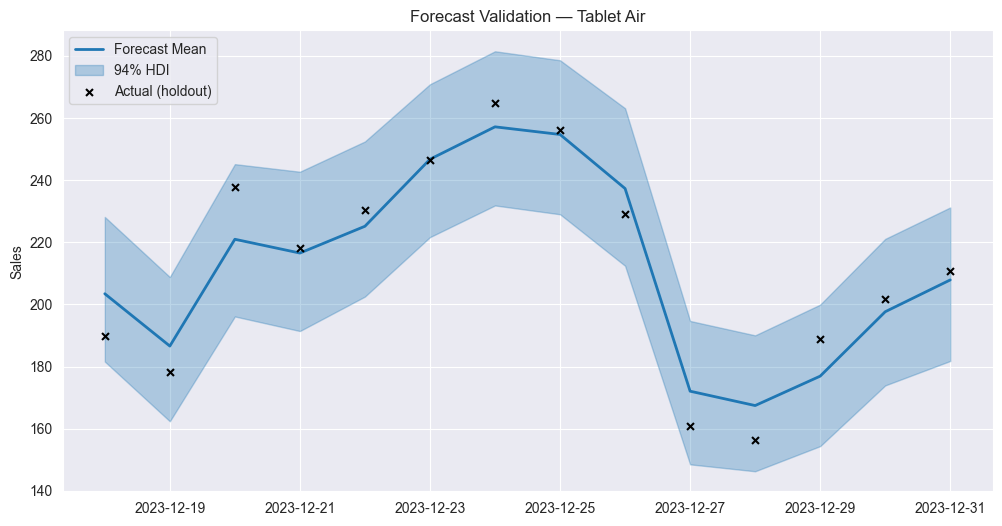

In [21]:
fig, ax = sk.plot_forecast("Tablet Air")

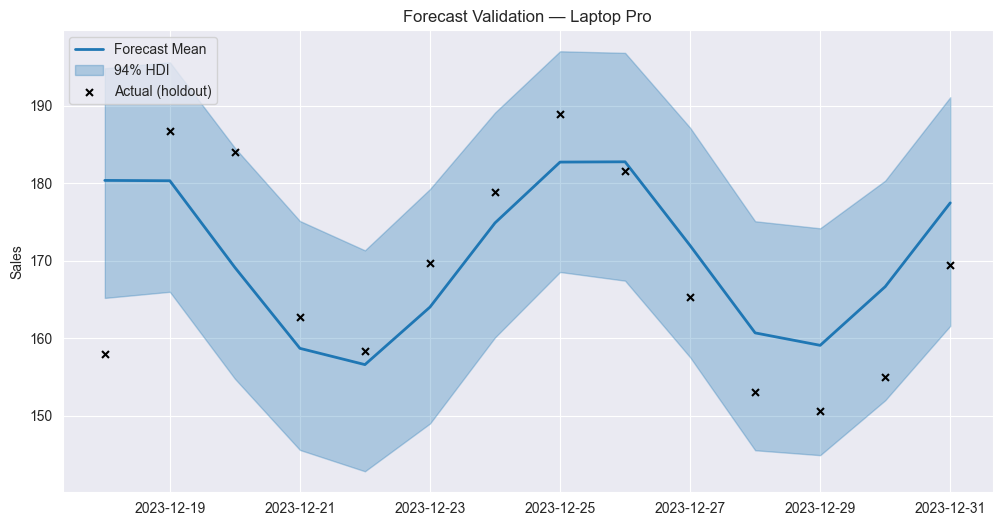

In [22]:
fig, ax = sk.plot_forecast("Laptop Pro")

## Solver diagnostic summary

`summary()` calls `ForecastSolver.summary()` on the last solve.  
It reports the distribution of portfolio profit across all posterior scenarios — useful for checking whether the CVaR tail is where you expected it to be.

In [23]:
summary = sk.summary()
for k, v in summary.items():
    if k == "allocation":
        continue
    if isinstance(v, dict):
        print(f"{k}:")
        for kk, vv in v.items():
            print(f"    {kk}: {vv:.2f}")
    elif isinstance(v, float):
        print(f"{k}: {v:,.2f}")
    else:
        print(f"{k}: {v}")

expected_profit: 844,985.91
profit_std: 204,747.21
cvar_10pct: 428,151.36
service_level: 0.00
certainty_equivalent: nan
risk_premium: nan
shadow_prices:
    storage_m3: 64.26


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:237: RuntimeWarning: divide by zero encountered in divide
  eu = float(np.mean(np.exp(-profits / self.risk_aversion)))
C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:238: RuntimeWarning: invalid value encountered in scalar multiply
  ce = float(-self.risk_aversion * np.log(max(eu, 1e-300)))


---
## Visualising the Results

`StockKeep` exposes four plot methods that progressively zoom in from the portfolio level down to individual item economics.  
The new `plot_suite` functions also accept `ForecastSolver` objects directly via `solver_to_problems()`, so you can skip manual extraction of demand samples entirely.

| Method / Function | Scope | What it shows |
|---|---|---|
| `sk.plot_allocation()` | Portfolio | Order quantities + constraint utilisation + demand distributions |
| `sk.plot_item(name)` | Single item | Demand distribution vs Q\* and expected profit curve |
| `sk.plot_optimization_summary()` | Portfolio | Potential vs realised profit waterfall + shadow prices |
| `sk.plot_risk()` | Portfolio | Simulated profit distributions across scenario draws |
| `plot_forecast_with_allocation()` | Single item | Time-series forecast → demand posterior → profit curve (full pipeline view) |

### Portfolio Allocation Plot

`plot_allocation()` gives a full portfolio overview in one figure:

- **Constraint gauges (top row):** how much of each resource limit has been consumed. Green = headroom remaining, red = over budget.
- **Order quantities (middle):** Q\* for each item. Items with higher underage costs relative to overage costs (higher critical fractile) tend to receive larger safety buffers.
- **Demand distributions (bottom left):** posterior total demand for the planning window overlaid for all items on a shared axis, with a dashed vertical line at Q\*. The fraction of the distribution to the *left* of Q\* is the service level — it should match the critical fractile.
- **Profit curves (bottom right):** expected profit as a function of order quantity. Q\* sits at or near the peak; the curve is asymmetric because over-stocking loses only the overage cost while under-stocking loses the full margin.

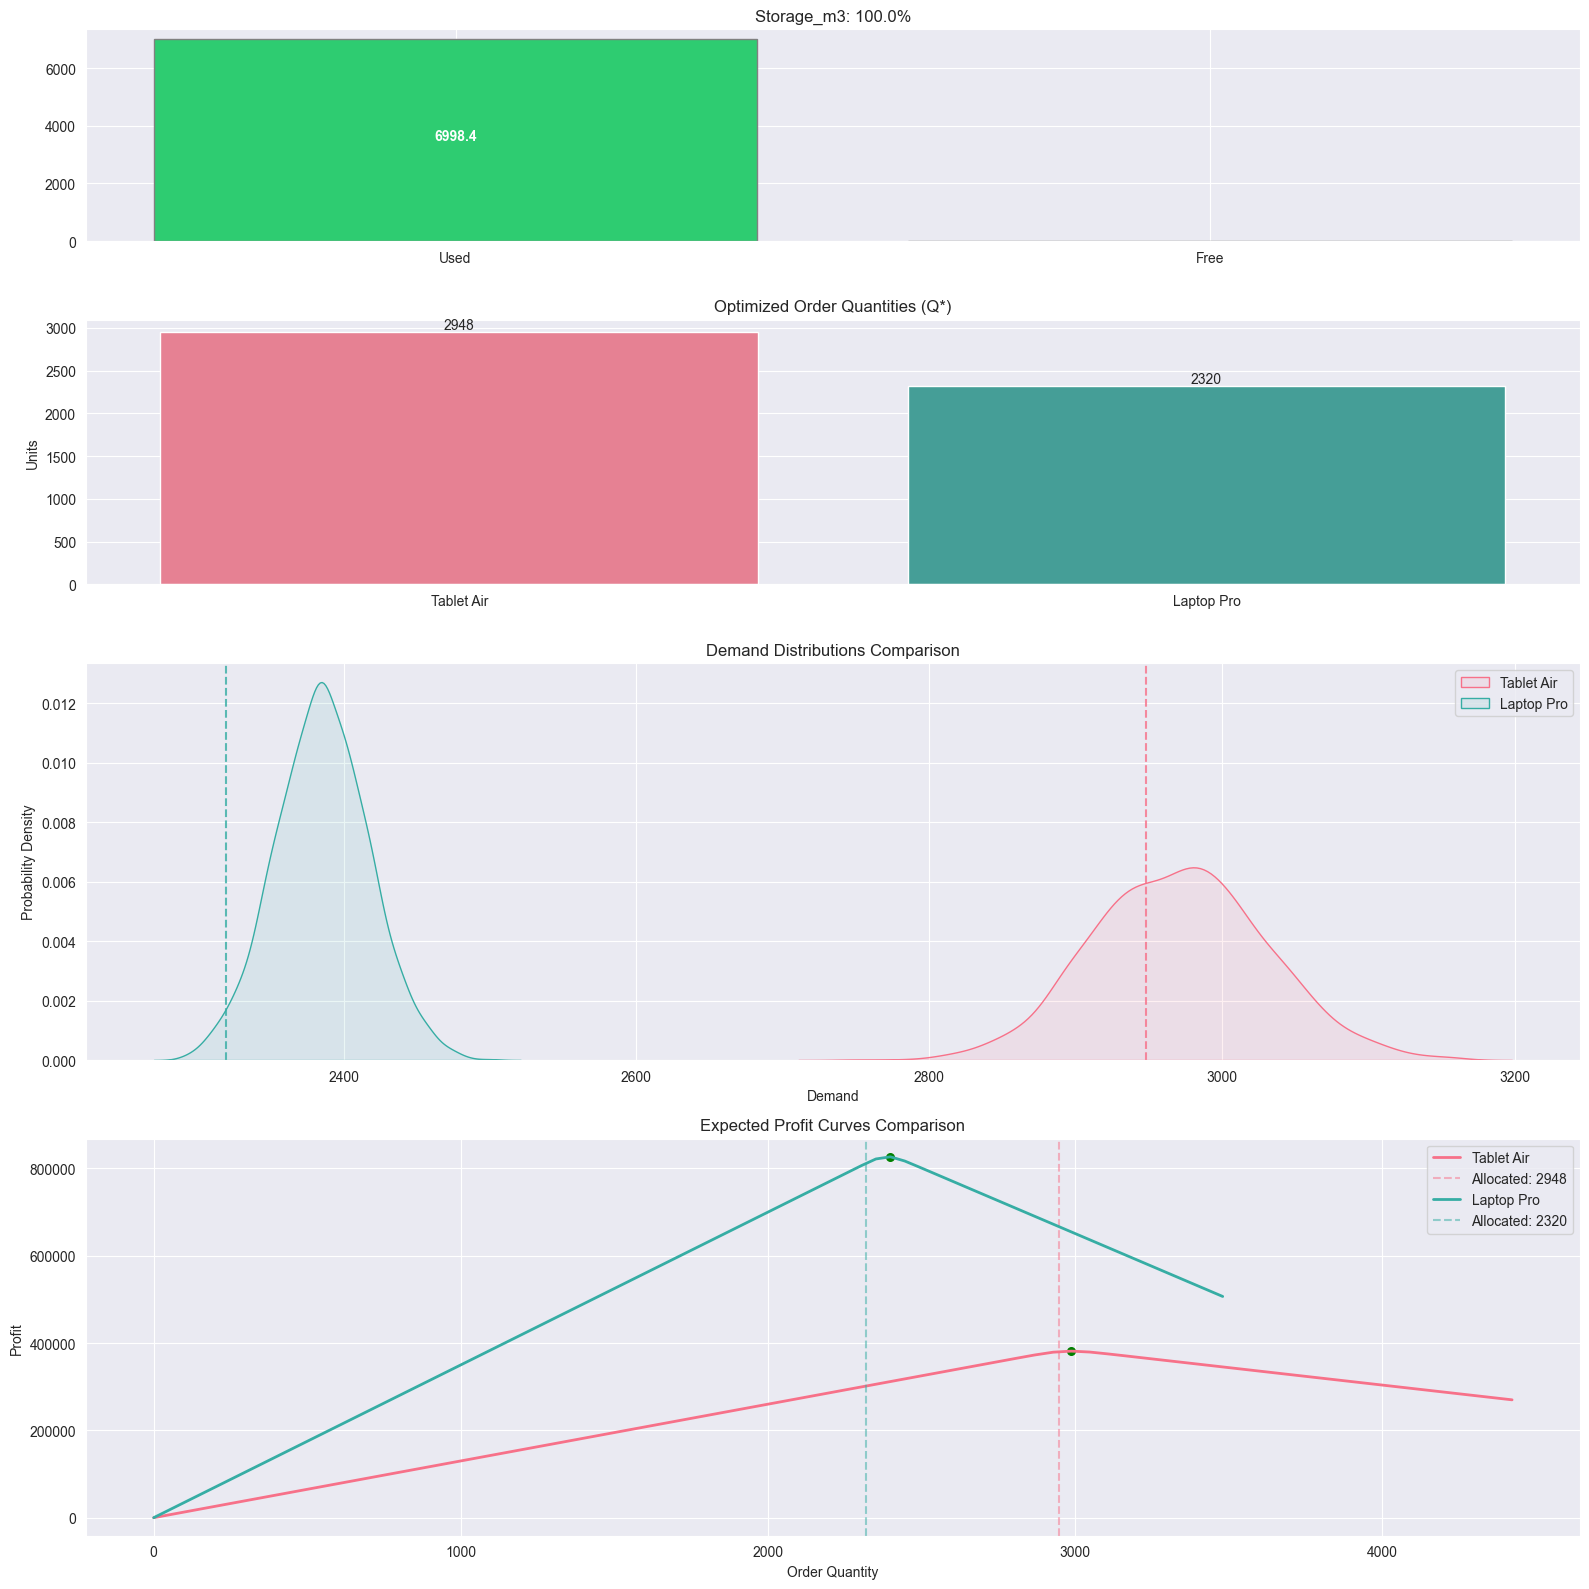

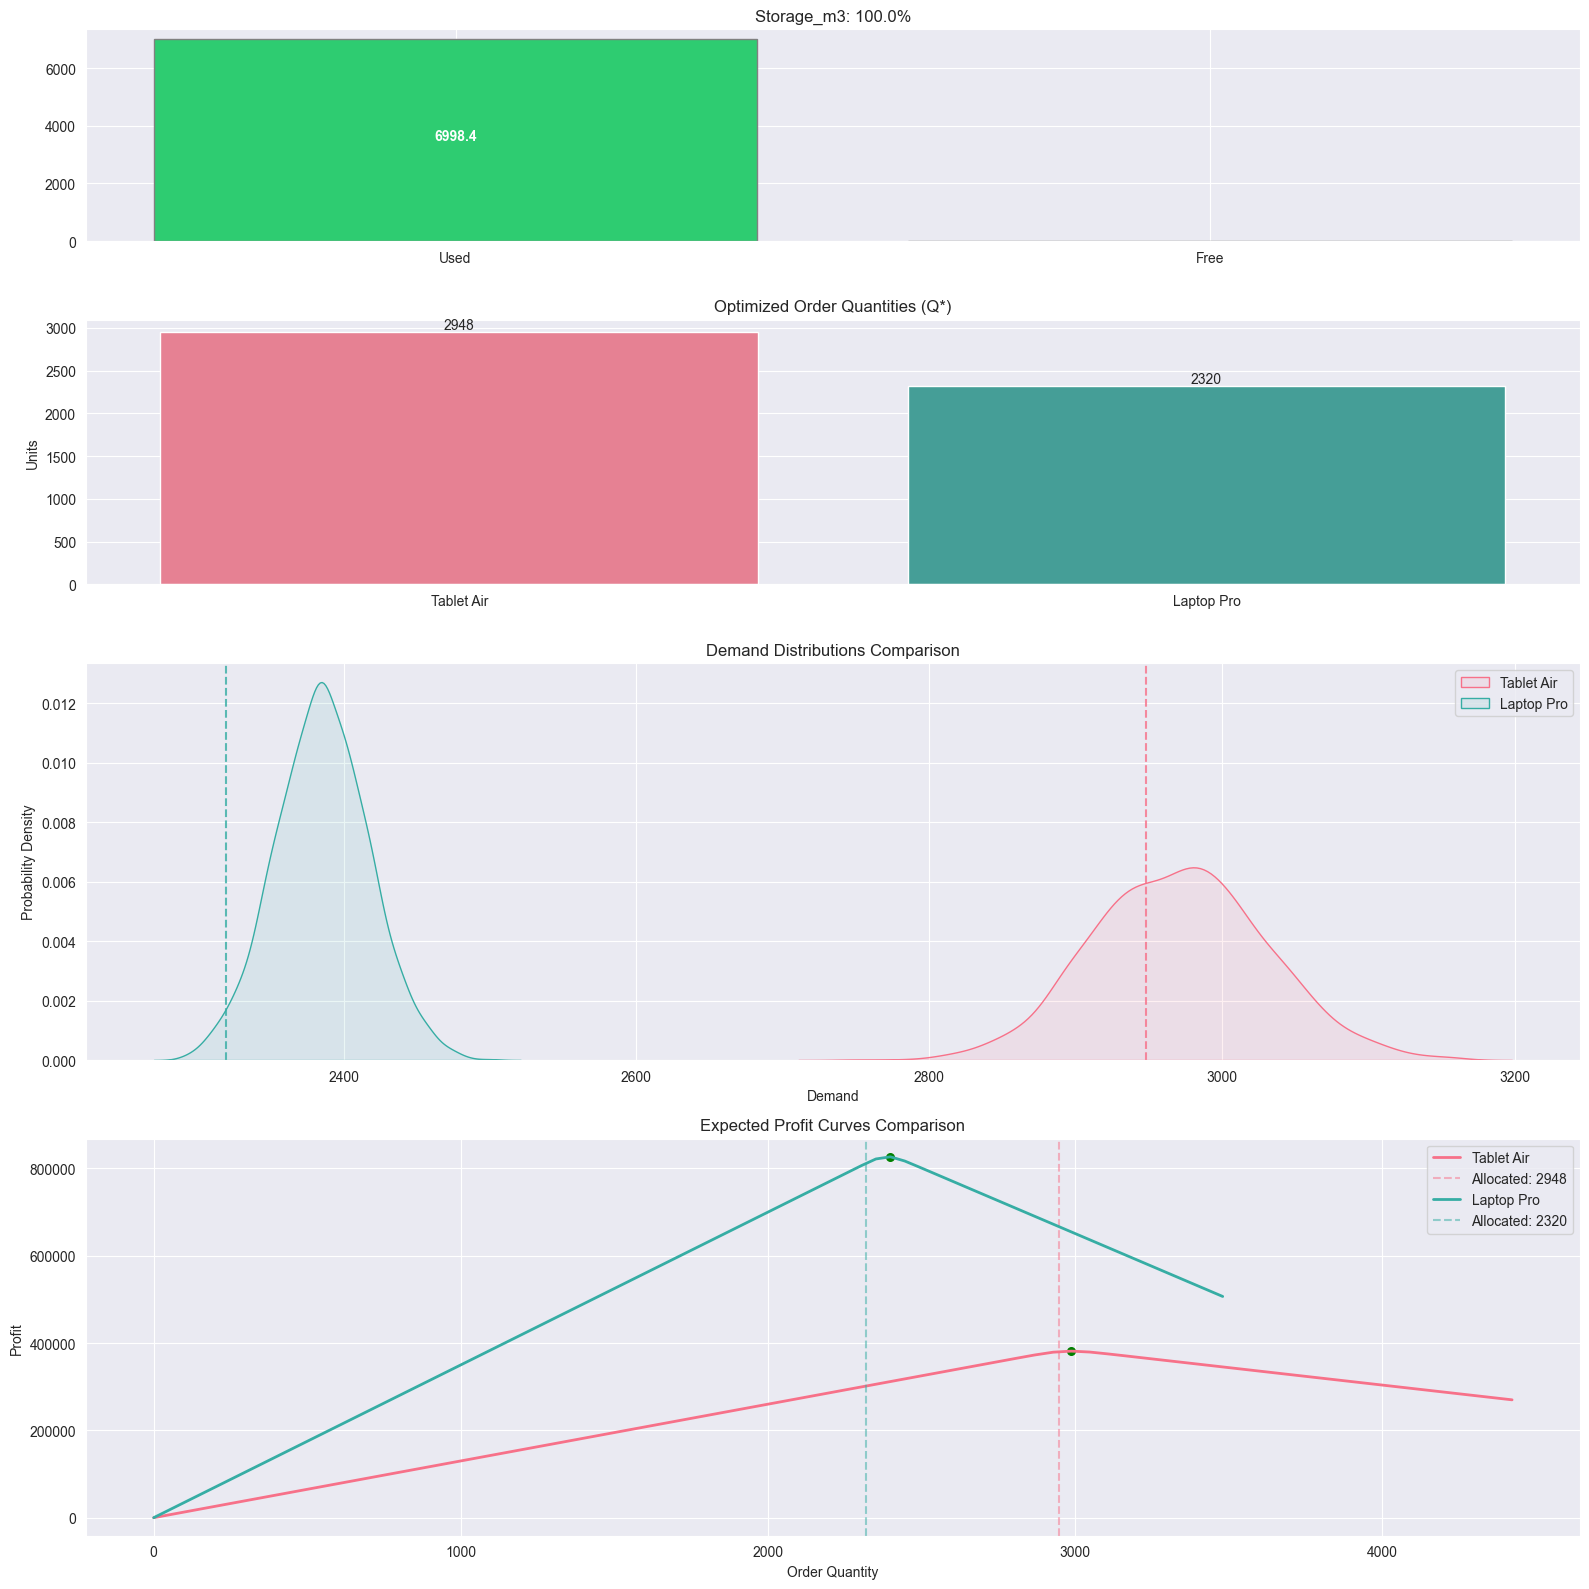

In [24]:
sk.plot_allocation()

### Single-Item Dashboard

`plot_item(name)` drills into a single item with a side-by-side view:

- **Left — Demand distribution:** a histogram and KDE of the posterior demand samples drawn by the forecaster. The dashed line marks Q\*. If Q\* sits far to the right of the distribution's mass the item is being over-stocked (perhaps pushed left by a binding constraint); if it sits inside the left tail the solver is cutting quantities to respect a resource limit.
- **Right — Profit curve:** the expected profit surface computed by Monte Carlo over the posterior samples. The green dot marks the unconstrained optimum; the dashed line marks the actual allocated Q\*. The gap between the two reveals the *constraint cost* for this item.

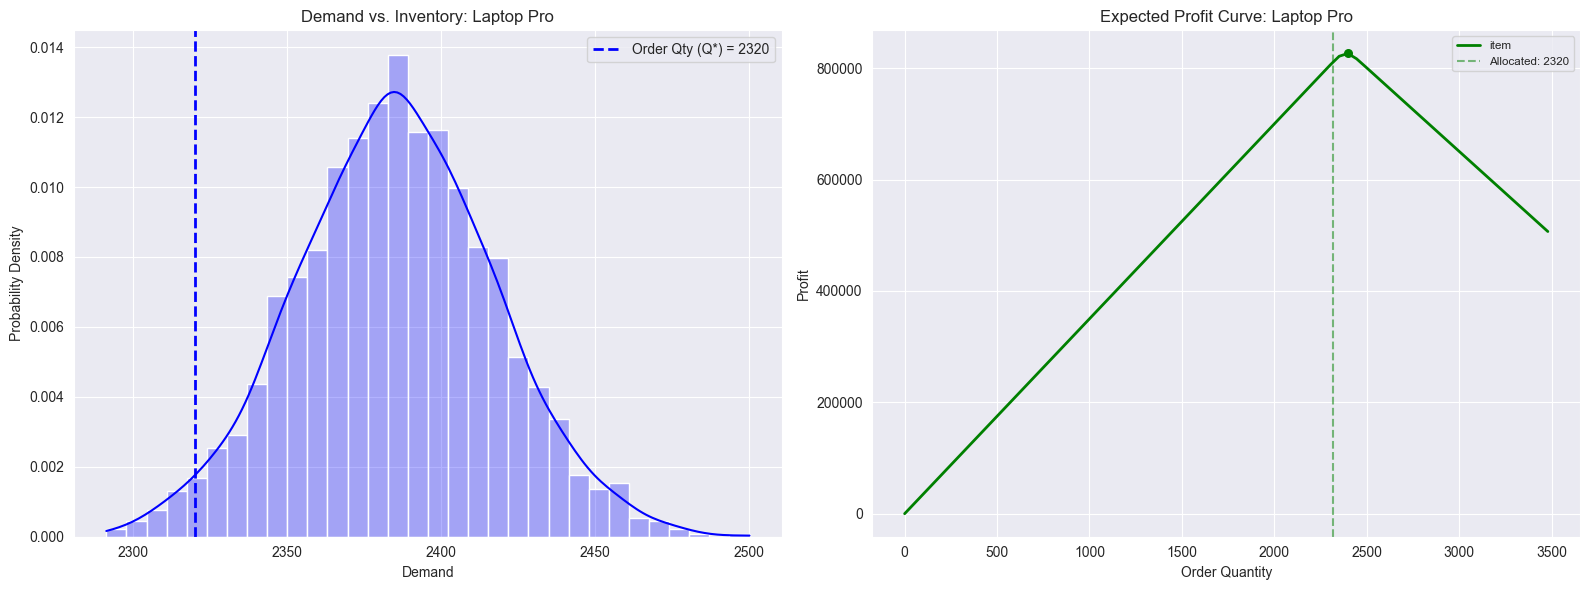

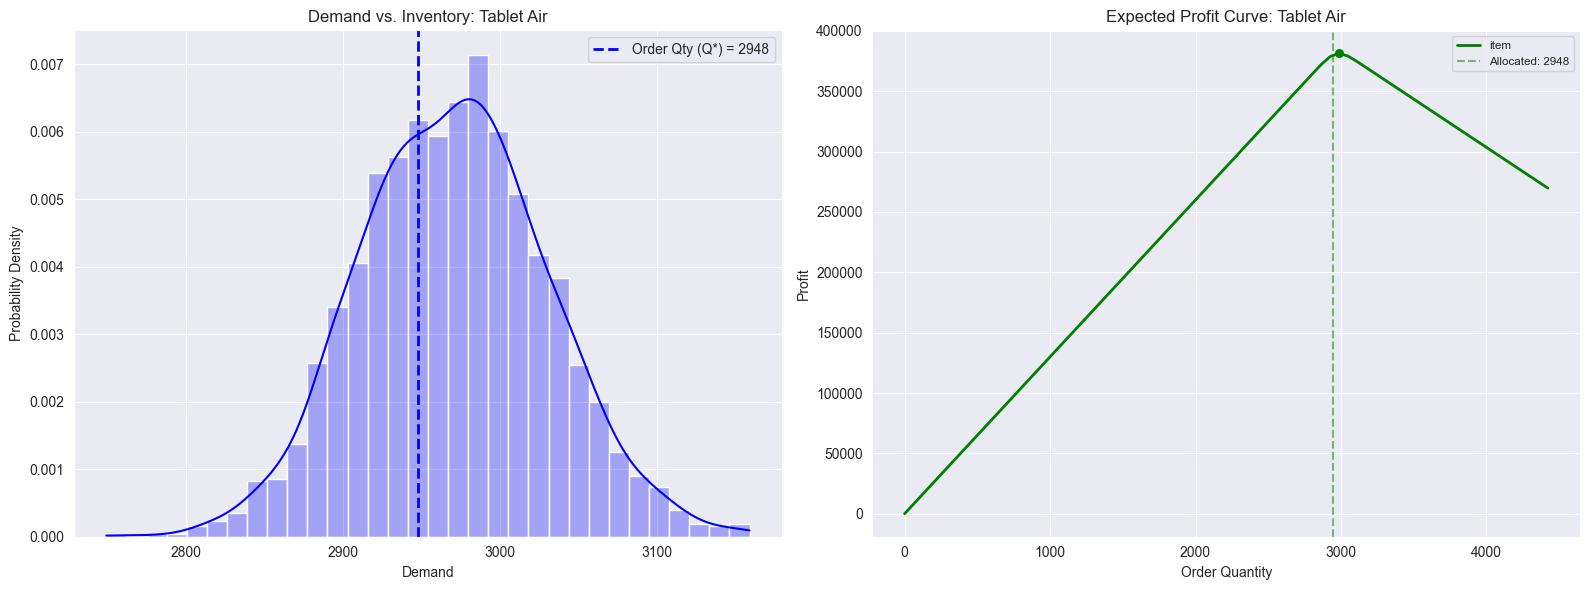

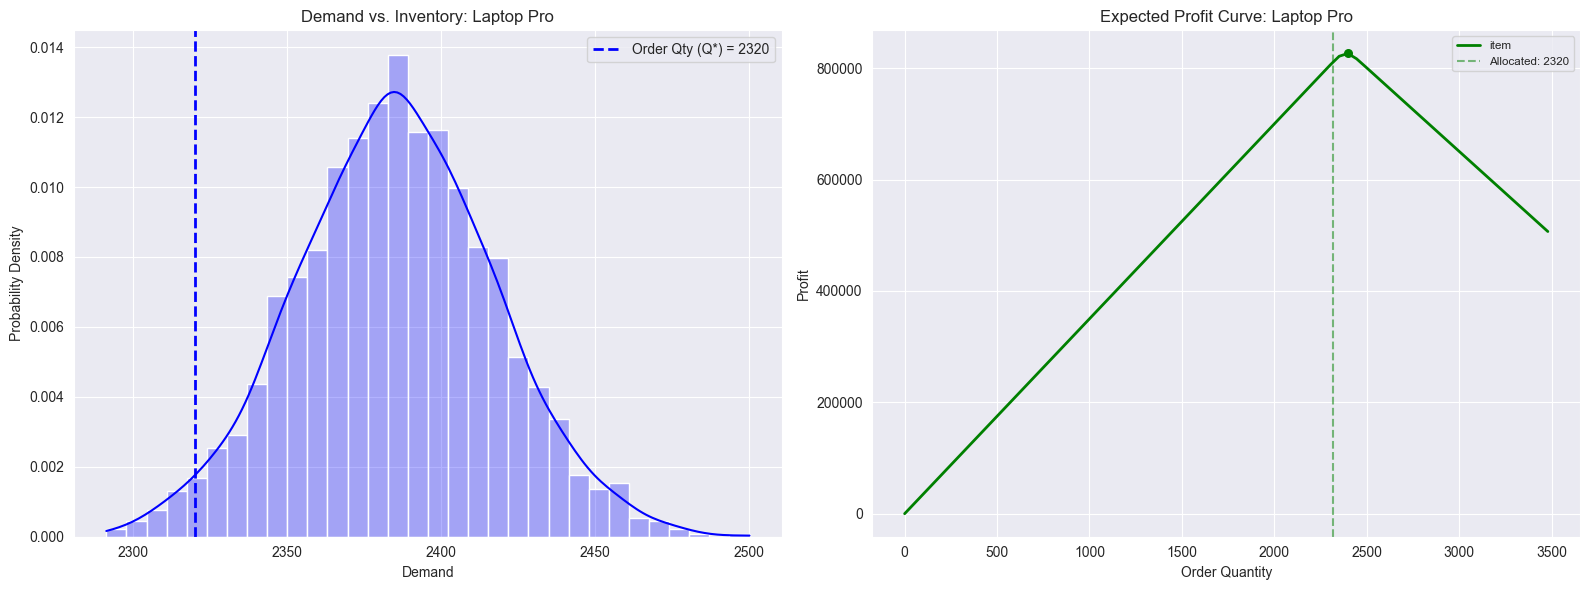

In [25]:
sk.plot_item("Tablet Air")
sk.plot_item("Laptop Pro")

### Optimisation Summary

`plot_optimization_summary()` answers: *"how much profit did the storage constraint cost us?"*

- **Potential vs Realised (top left):** the grey bar is the total profit if every item were ordered at its unconstrained Q\* (critical fractile solution with no resource limits). The green bar is the realised profit under the constrained allocation. The title shows the absolute constraint cost.
- **Shadow prices / Lagrangian multipliers (top right):** the dual variable on the storage constraint. Interpreted as: *"relaxing the storage limit by 1 m³ would increase expected profit by £X."* A high shadow price signals the constraint is actively binding — increasing warehouse capacity would be high-ROI. A shadow price near zero means the constraint has headroom.
- **Per-item profit contribution (bottom):** ranked bar chart. Items with a wide margin between selling price and salvage value appear here as high contributors; items with thin margins or tight constraints appear lower.

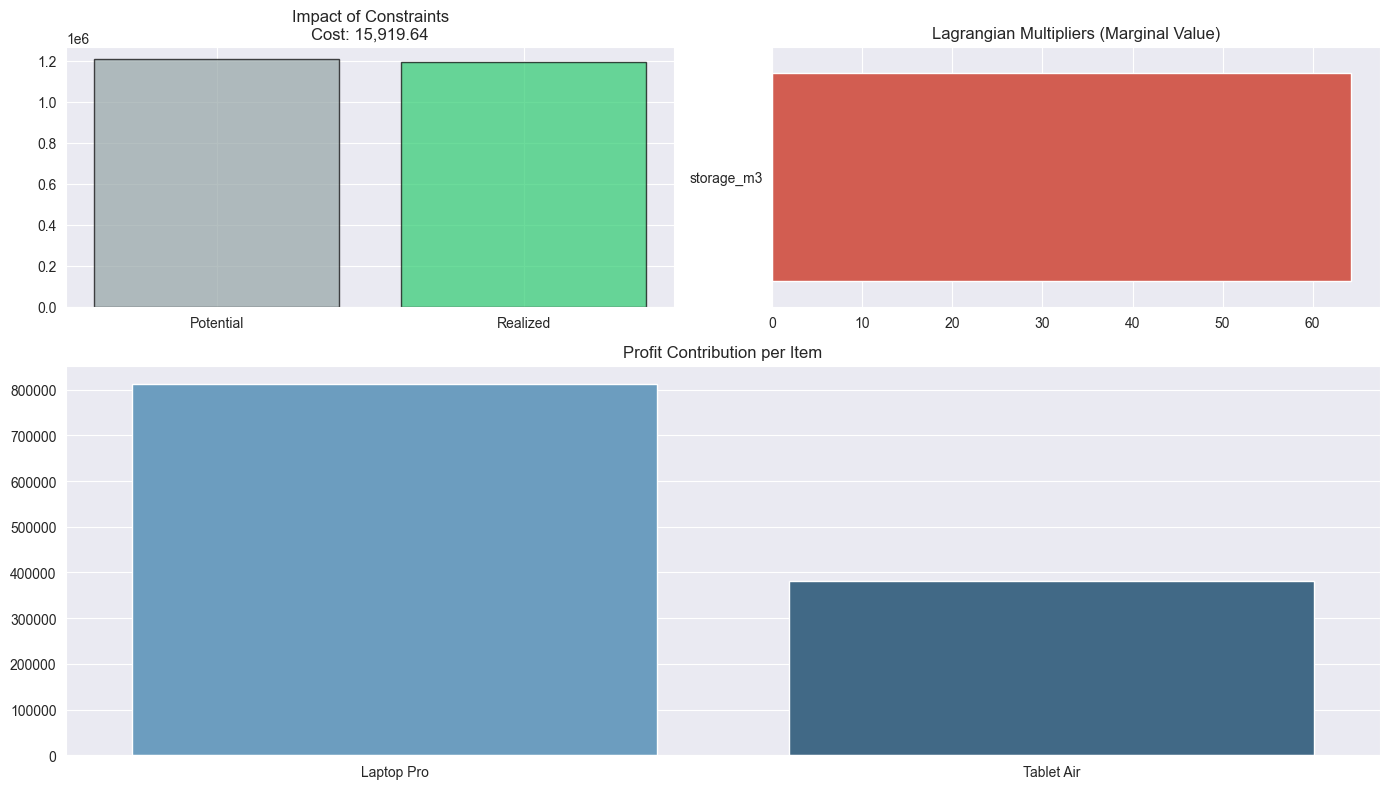

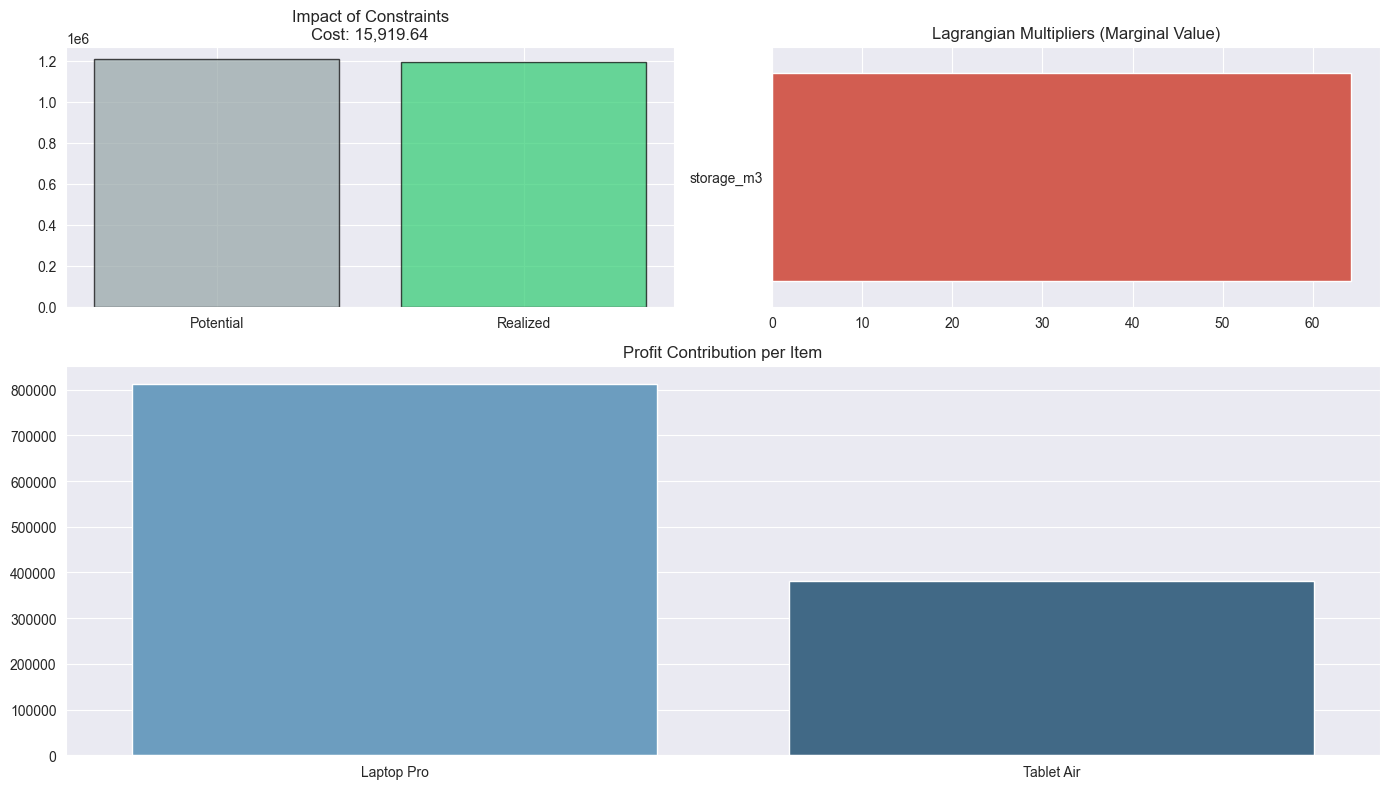

In [26]:
sk.plot_optimization_summary()

### Risk Profile

`plot_risk()` simulates the full portfolio profit distribution — not just its expectation — by running the posterior demand and yield samples through the newsvendor payoff function for every scenario.

- **KDE curves:** each strategy's profit distribution. A wider spread means more outcome uncertainty; a heavier left tail means more downside risk.
- **Dashed vertical lines:** the mean profit for each strategy.
- **Dotted vertical lines:** the CVaR at the 5th percentile (worst 5% of scenarios). This is the "expected loss in a bad quarter" number that risk-averse managers care about.
- **Summary table:** a quick numerical comparison across strategies.

> **CVaR vs SAA trade-off:** the CVaR objective often produces a slightly lower *expected* profit than SAA, but the worst-case outcomes are significantly better. Whether that trade-off is worthwhile depends on the firm's risk appetite.

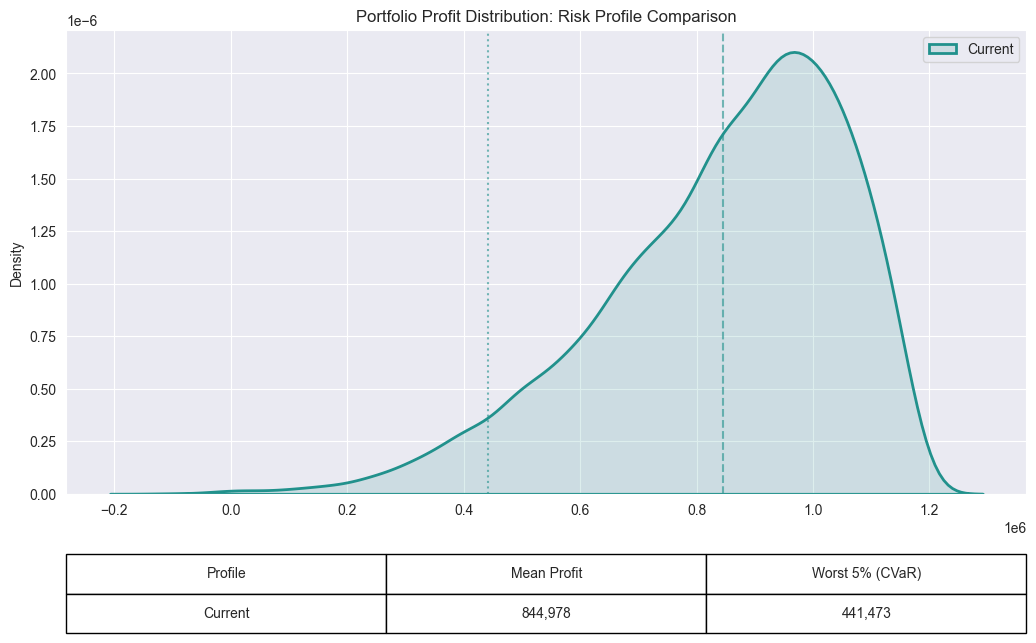

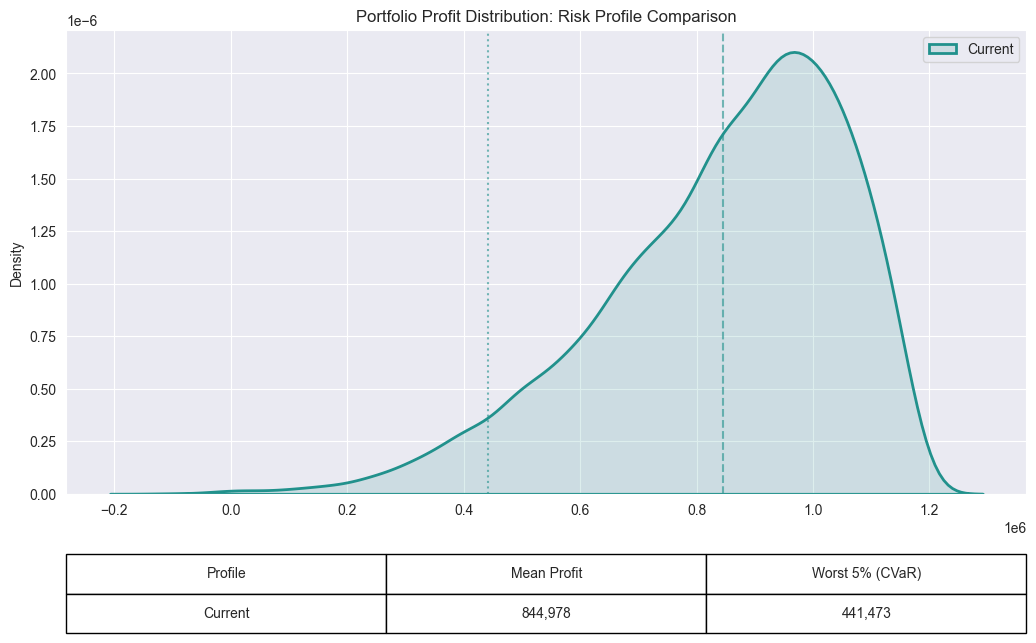

In [27]:
sk.plot_risk()

---
### Forecast + Allocation Dashboard

`plot_forecast_with_allocation()` is the **full-pipeline view** — it connects the time-series forecast to the inventory decision in a single figure, making it easy to communicate the methodology to stakeholders.

The three panels read left-to-right as a causal chain:

1. **Forecast (left):** the model's posterior predictive for each day in the planning window, shown as mean ± 94% HDI. The uncertainty band captures both parameter uncertainty and observation noise — a wider band means the model is less confident about the level of demand for this particular period.

2. **Demand distribution (centre):** the posterior samples are *summed* across all days in the planning window to give a single distribution of *total* period demand. This is the distribution that the newsvendor problem is solved against. The dashed line marks Q\* — roughly, the critical fractile of this distribution.

3. **Profit curve (right):** the expected profit as a function of order quantity, computed by Monte Carlo over the posterior demand samples. The curve peaks at the unconstrained optimum (green dot); Q\* may sit slightly left of this peak if a resource constraint is binding.

> **Reading this plot:** if the demand distribution (panel 2) is wide, the forecast is uncertain → the profit curve (panel 3) will be flatter around its peak, meaning the cost of mis-ordering is relatively low. If the distribution is narrow, the profit curve will be sharper, and Q\* matters more.

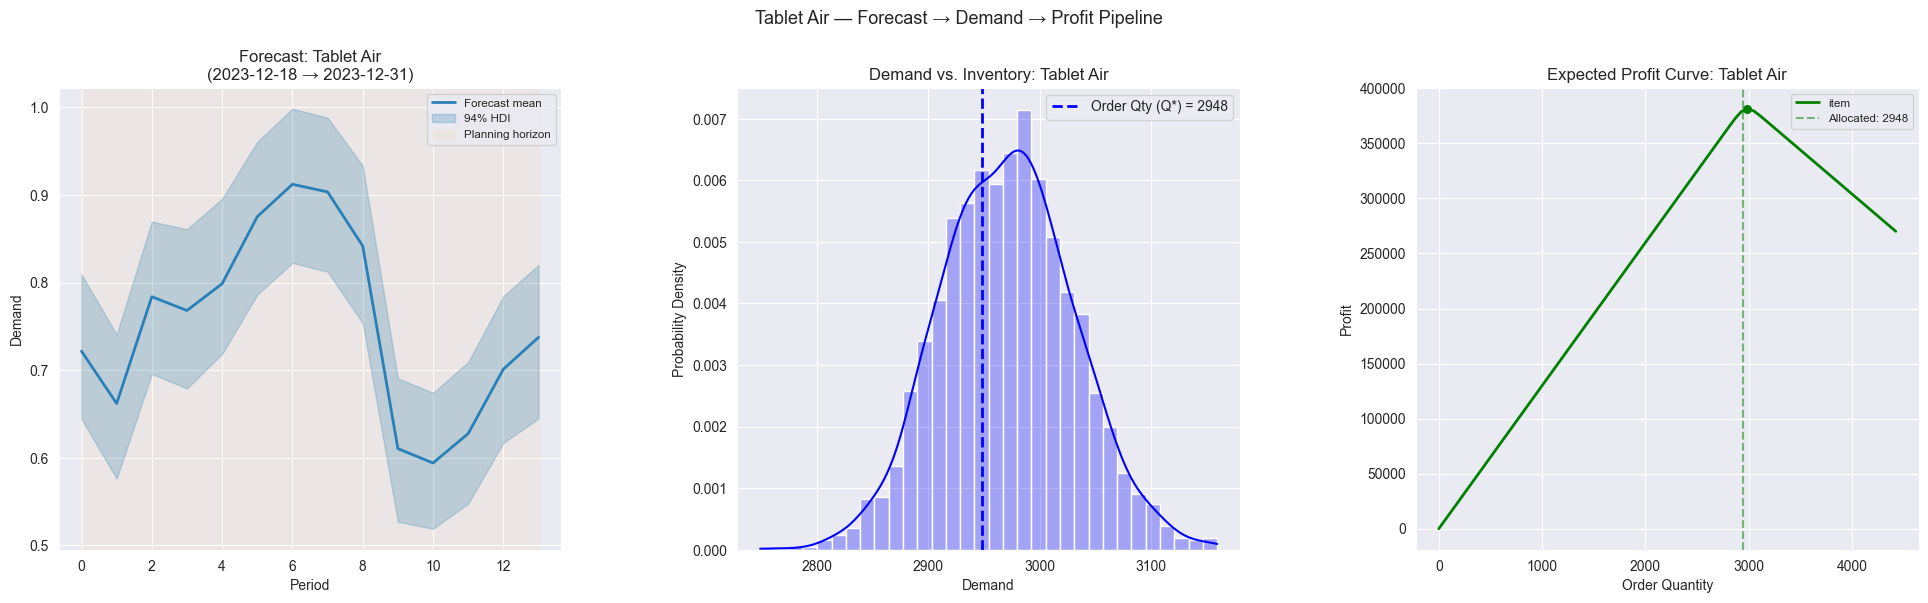

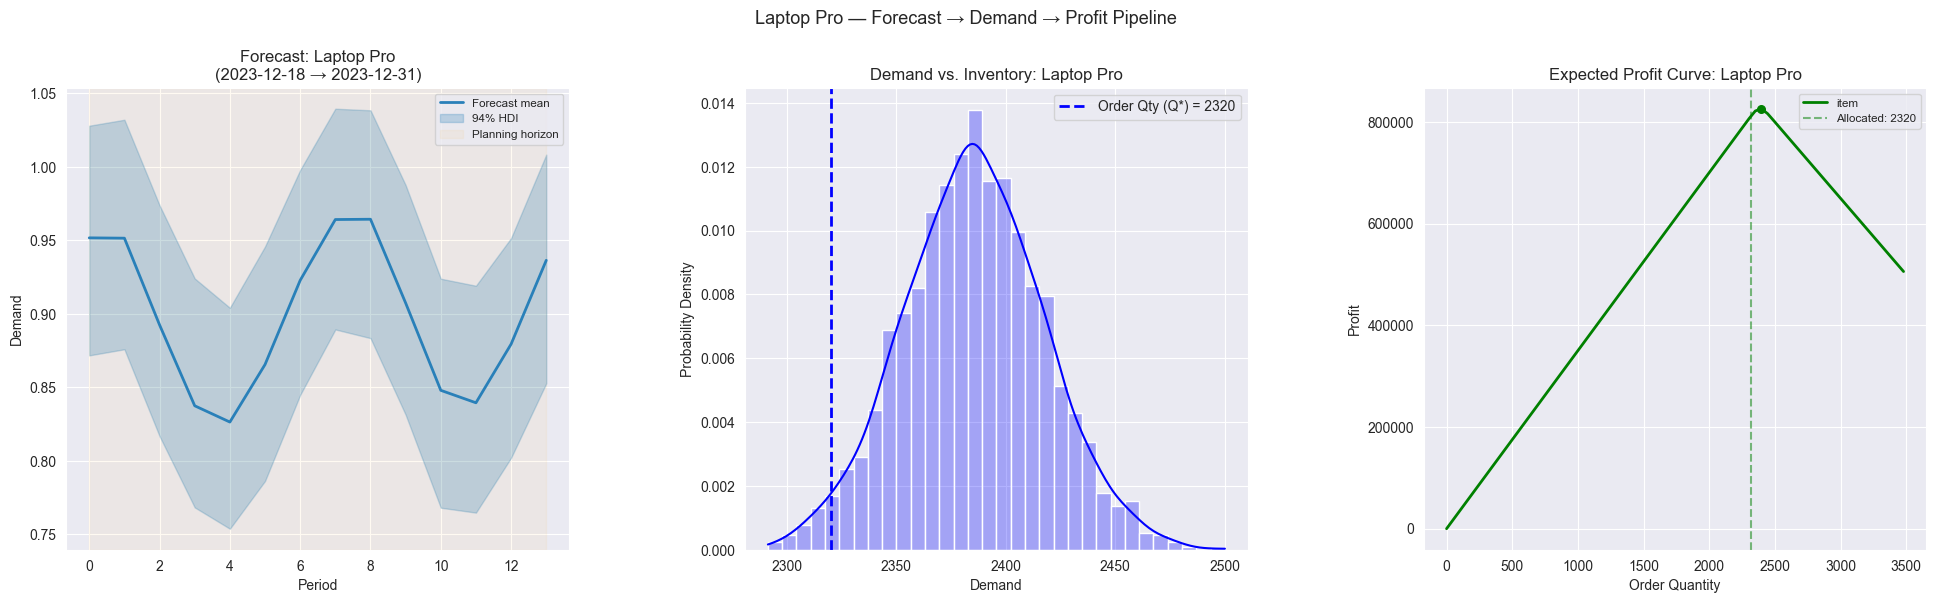

In [28]:
from optistock.plot_suite import plot_forecast_with_allocation

start, end = holdout_results["period"]

for item in sk.items:
    forecaster = sk.trained_forecasters[item.name]
    qty        = holdout_results["allocation"][item.name]
    fig = plot_forecast_with_allocation(item, forecaster, qty, start, end)
    fig.suptitle(f"{item.name} — Forecast → Demand → Profit Pipeline", y=1.01, fontsize=13)
    plt.show()

---
### Working with `plot_suite` Directly via `solver_to_problems()`

The `StockKeep.plot_*()` methods are convenient wrappers, but you sometimes want to call the underlying `plot_suite` functions directly — for example to customise figure layout, overlay additional data, or compare allocations from different solver runs.

`solver_to_problems(solver)` is the bridge: it reads the posterior demand matrices already stored inside the `ForecastSolver` after `solve()` and wraps them as `SampledDemand` objects. This means:

- **No re-fitting:** the demand samples used for plotting are exactly the same ones the optimiser saw — no extra randomness.
- **Non-parametric:** the `SampledDemand` wrapper passes raw samples to all plot functions. Histograms, KDE curves, and profit simulations all use the actual posterior draws, so skewed or multi-modal posteriors are represented faithfully.
- **Consistent with the solver:** Q\* lines and profit curves are computed from the same demand distribution the solver used to find Q\*.

```python
from optistock.plot_suite import solver_to_problems, plot_constrained_allocation

problems = solver_to_problems(sk.solver)          # → [(Item, SampledDemand), ...]
fig = plot_constrained_allocation(
    sk.solver.allocation,
    problems,
    sk.solver.limits,
)
```

In [29]:
from optistock.plot_suite import (
    solver_to_problems,
    plot_constrained_allocation,
    plot_optimization_summary,
)

# Extract (Item, SampledDemand) pairs from the solver — same samples the optimiser used
problems = solver_to_problems(sk.solver)

print("solver_to_problems() output:")
for item, demand in problems:
    print(f"  {item.name:12s}  samples={len(demand.samples):,}  "
          f"mean={demand.mean:,.0f}  std={demand.std:,.0f}  "
          f"Q5={demand.get_quantile(0.05):,.0f}  Q95={demand.get_quantile(0.95):,.0f}")

solver_to_problems() output:
  Tablet Air    samples=2,000  mean=2,971  std=59  Q5=2,878  Q95=3,069
  Laptop Pro    samples=2,000  mean=2,385  std=32  Q5=2,332  Q95=2,439


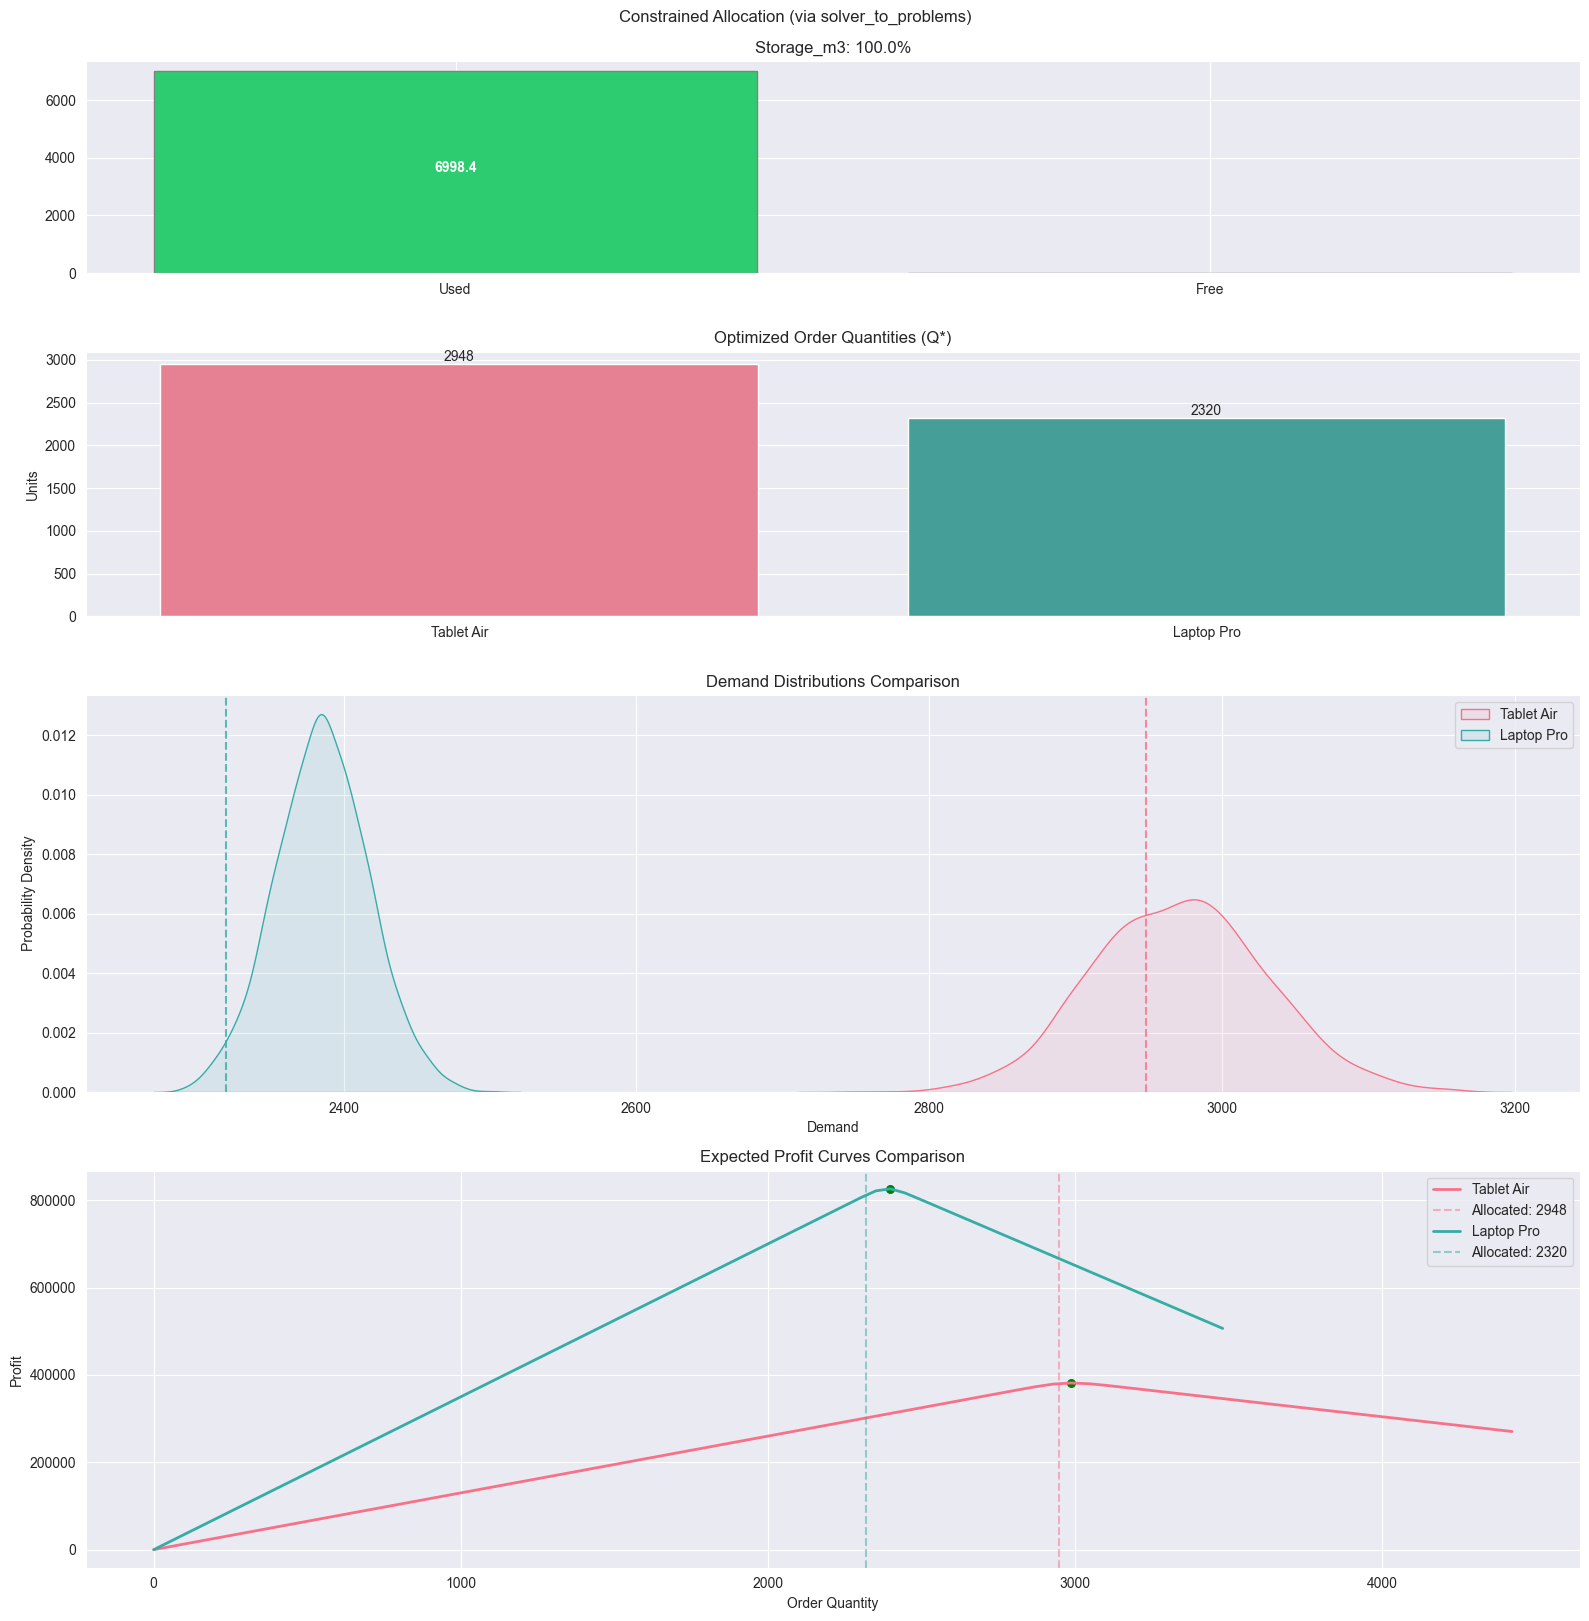

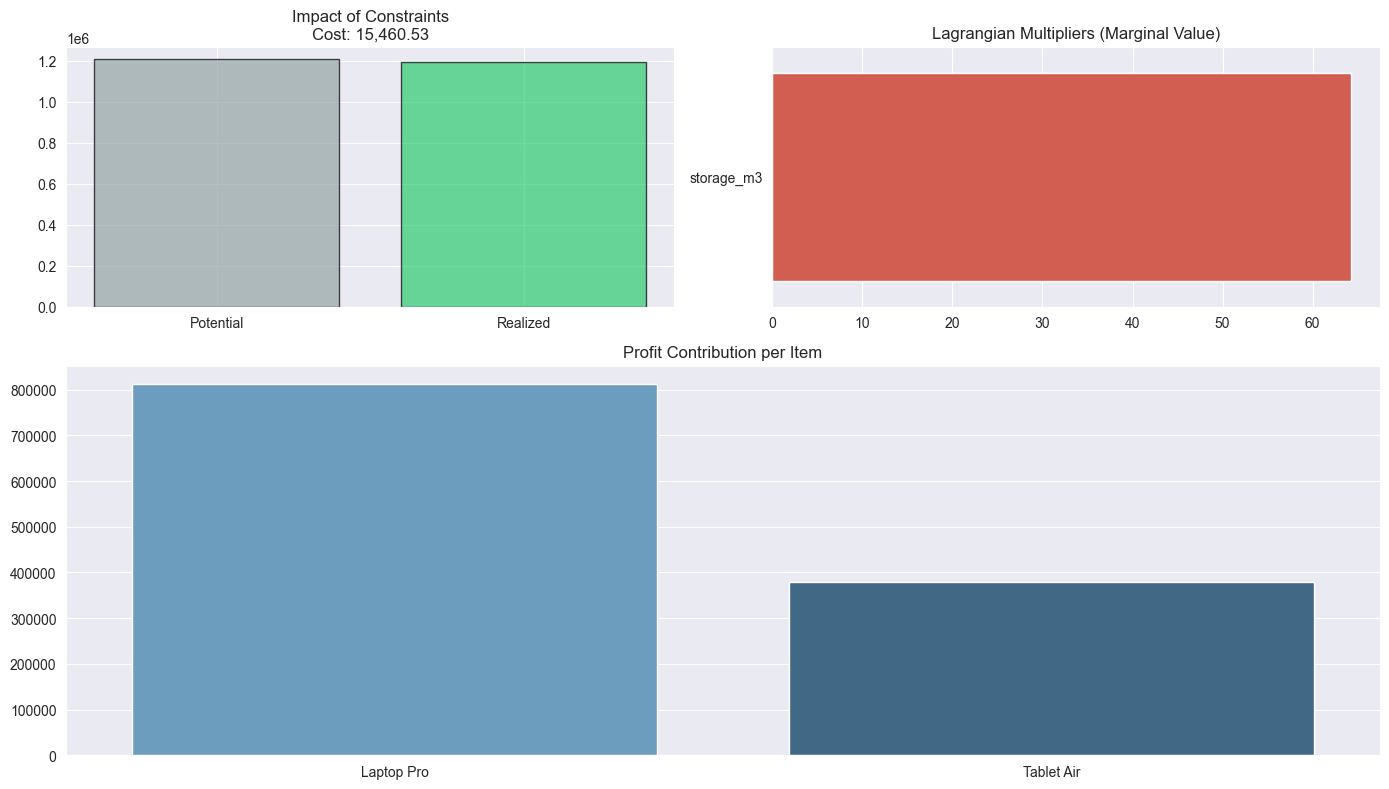

In [30]:
# Call plot_suite functions directly with the solver's demand samples
fig = plot_constrained_allocation(
    sk.solver.allocation,
    problems,
    sk.solver.limits,
)
fig.suptitle("Constrained Allocation (via solver_to_problems)", y=1.01)
plt.show()

fig = plot_optimization_summary(
    sk.solver.allocation,
    problems,
    lambdas=sk.solver.shadow_prices,   # pass shadow prices directly from solver
)
plt.show()

---
## Production Run

Once you are satisfied with the holdout results, switch to `run()` to commit to a production allocation.

`run()` fits on the **full** history for each item (no data is withheld) and forecasts `forecast_days` days beyond the last observed date. It returns the same `allocation` and `solver_summary` fields, but no holdout `metrics` (there is no ground truth to compare against yet).

Here we switch to the SAA objective — pure expected-profit maximisation — now that we have validated the approach in holdout mode.

In [31]:
production_results = sk.run(
    forecast_days=14,
    events=events,
    objective="SAA",
    limits={"storage_m3": 7_000},
    fit_kwargs={"chain": 2, "samples": 500},
)

print("Planning period :", production_results["period"])
print("Mode            :", production_results["mode"])
print()

allocation_prod = production_results["allocation"]
for item_name, qty in allocation_prod.items():
    print(f"  {item_name:12s}  →  order {qty:>6,} units")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 20 seconds.
Sampling: [y]


Output()

Sampling: [y]


...

Output()

Sampling: [y]


Output()

Planning period : ('2024-01-01', '2024-01-14')
Mode            : production

  Tablet Air    →  order  2,604 units
  Laptop Pro    →  order  2,458 units


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:237: RuntimeWarning: divide by zero encountered in divide
  eu = float(np.mean(np.exp(-profits / self.risk_aversion)))
C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:238: RuntimeWarning: invalid value encountered in scalar multiply
  ce = float(-self.risk_aversion * np.log(max(eu, 1e-300)))


In [32]:
production_results_CVaR = sk.run(
    forecast_days=14,
    events=events,
    objective="CVaR",
    cvar_alpha = 0.1,
    cvar_lambda = 0.7,
    limits={"storage_m3": 7_000},
    fit_kwargs={"chain": 2, "samples": 500},
)

print("Planning period :", production_results_CVaR["period"])
print("Mode            :", production_results_CVaR["mode"])
print()

allocation_prod_CVaR = production_results_CVaR["allocation"]
for item_name, qty in allocation_prod_CVaR.items():
    print(f"  {item_name:12s}  →  order {qty:>6,} units")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 20 seconds.
Sampling: [y]


Output()

Sampling: [y]


...

Output()

Sampling: [y]


Output()

Planning period : ('2024-01-01', '2024-01-14')
Mode            : production

  Tablet Air    →  order  2,642 units
  Laptop Pro    →  order  2,442 units


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:237: RuntimeWarning: divide by zero encountered in divide
  eu = float(np.mean(np.exp(-profits / self.risk_aversion)))
C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:238: RuntimeWarning: invalid value encountered in scalar multiply
  ce = float(-self.risk_aversion * np.log(max(eu, 1e-300)))


Text(0.5, 1.01, 'Laptop Pro — 14-day production forecast')

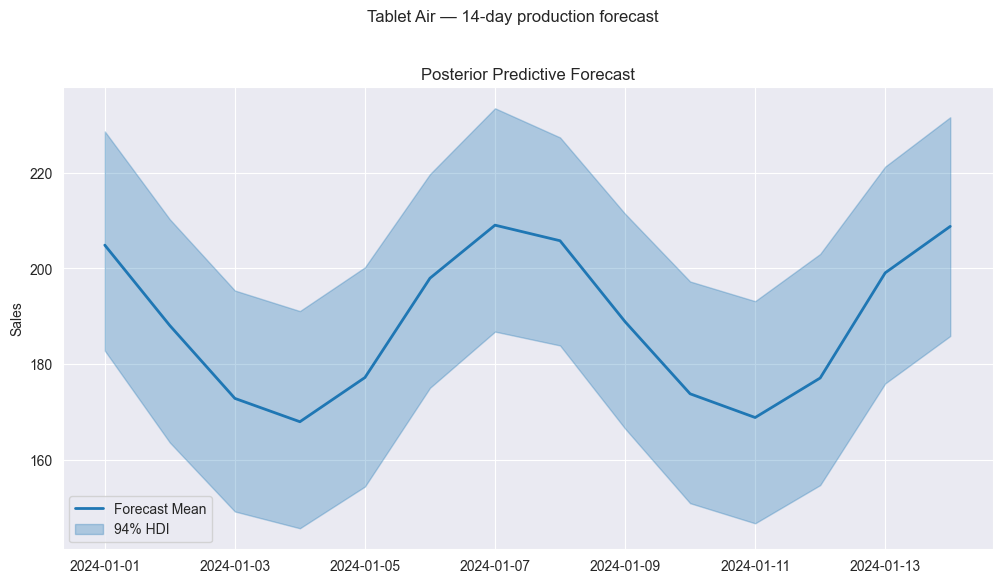

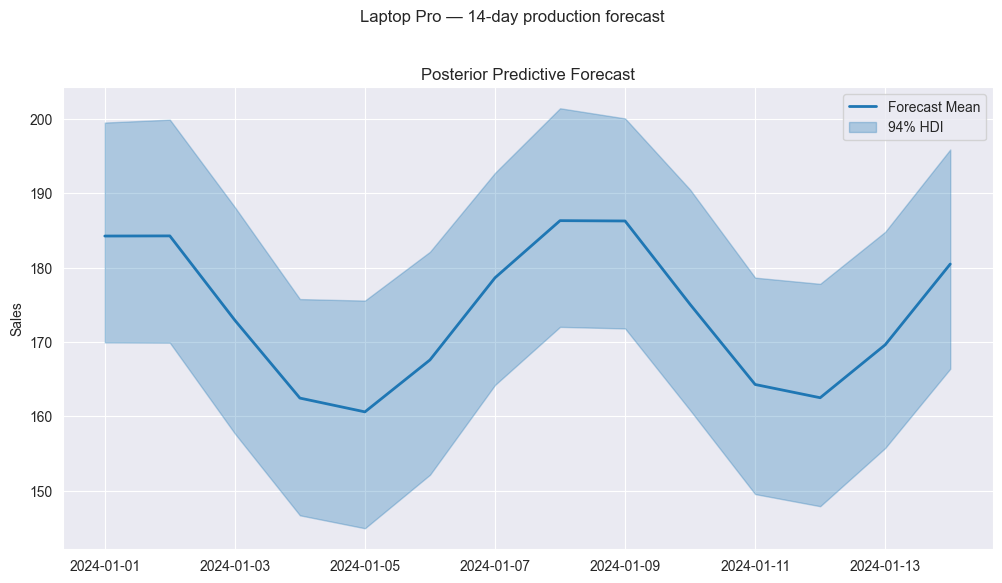

In [33]:
# Forecast plots for the production window (no holdout actuals to overlay)
fig_ta, _ = sk.plot_forecast("Tablet Air")
fig_ta.suptitle("Tablet Air — 14-day production forecast", y=1.01)

fig_lp, _ = sk.plot_forecast("Laptop Pro")
fig_lp.suptitle("Laptop Pro — 14-day production forecast", y=1.01)

---
## Risk Comparison: CVaR (Holdout) vs SAA (Production)

The two runs above used different objectives: `CVaR` in holdout mode and `SAA` in production. 
`plot_risk_comparison()` lets you overlay their profit distributions on a single chart to quantify the trade-off.

Pass allocations as plain dicts alongside the `(Item, SampledDemand)` problems list. The function simulates profit for each scenario by re-sampling from the demand distribution.

> **What to look for:**
> - A **higher mean** (rightward mean line) = better expected profit.
> - A **higher CVaR** (rightward dotted line) = less downside risk.
> - A narrower distribution = more predictable outcomes.
>
> SAA typically has a higher mean but a heavier left tail; CVaR trades some mean profit for a better worst-case floor.

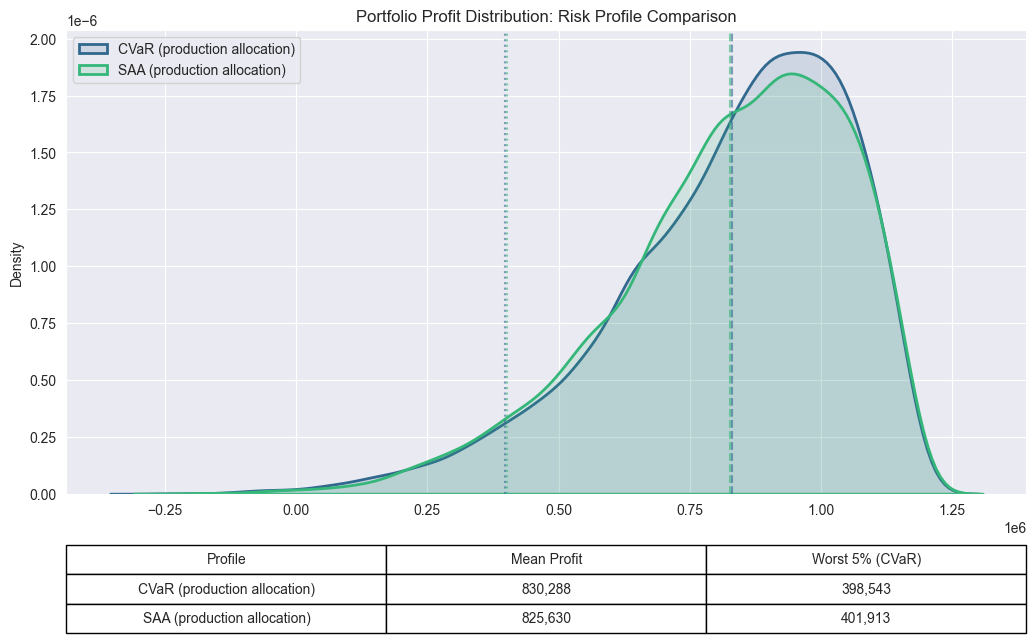

In [34]:
from optistock.plot_suite import plot_risk_comparison

# Use the holdout solver's demand samples as the shared evaluation base
# (both allocations are evaluated against the same posterior draws)
eval_problems = solver_to_problems(sk.solver)

fig = plot_risk_comparison(
    allocations={
        "CVaR (production allocation)":    allocation_prod_CVaR,
        "SAA (production allocation)":  allocation_prod,
    },
    problems=eval_problems,
    n_sims=8_000,
)
plt.show()

---
## Summary

| Stage | Key object | What you get |
|---|---|---|
| Data prep | `df_history`, `item_configs` | Long-format sales + item economics |
| Orchestration | `StockKeep` | Single entry-point for fit → forecast → optimise → evaluate |
| Holdout validation | `run_holdout()` | Back-test strategy before going live; per-item SMAPE + profit metrics |
| Production | `run()` | Full-history fit + future allocation |
| Portfolio view | `sk.plot_allocation()` | Quantities, constraint gauges, demand distributions, profit curves |
| Single-item view | `sk.plot_item()` | Demand vs Q\* + profit curve for one item |
| Pipeline view | `plot_forecast_with_allocation()` | Forecast → demand posterior → profit curve in one figure |
| Constraint analysis | `sk.plot_optimization_summary()` | Waterfall chart + shadow prices |
| Risk analysis | `sk.plot_risk()` / `plot_risk_comparison()` | Full profit distribution + CVaR comparison |
| Direct plot_suite | `solver_to_problems(solver)` | Bridge solver → plot functions with the exact same demand samples |

### Next steps
- **Notebook 6** will cover multi-item problems with multiple simultaneous constraints (budget + storage + carbon units).
- To swap the forecaster, pass a different class to `StockKeep(forecaster_class=...)` — the rest of the pipeline is unchanged.